In [1]:
import sys
sys.path.append("../src")

In [2]:
from integrator import ComplexIntegrator
from context_manager import TriangleIntegrandEvaluator,TriangleIntegrandContext, spherical
import oneloop_bridge
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from integrand_builder import IntegrandBuilder
from wrapped_eval import WrappedEvaluator

# do this to trigger the banner here so it doesn't get in the way later
oneloop_bridge.set_renormalization_scale(1.0)

import symbolica as sb

rng = sb.RandomNumberGenerator(1, 0)

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

In [3]:
ctx = TriangleIntegrandContext()
ib = IntegrandBuilder()

# Problematic E-surface when not checking!

We can clearly see that the solution here is spurious, checking is therefore really necessary!
Might be worth to not check per sample, but per surface before evaluation, but then 

-13082.255306122443
[-69.21428571   0.           0.         -34.50532346]
4.18
172.76
Compiling evaluator: "root1"
Done!
Compiling evaluator: "root2"
Done!
Compiling evaluator: "eta"
Done!
(-0.86882194554482+0j)
2.220446049250313e-16j


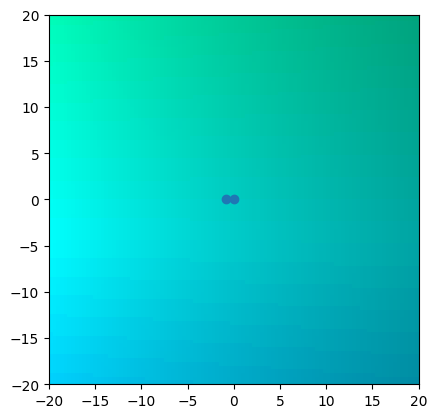

In [ ]:
ctx.set_anomalous_configuration(p2 = 200)

i = 1
j = 2

qs = ctx.get_args()[8:11]
m = ctx.get_args()[5:8]

q = (qs[i]-qs[j])/2

test = 4*q[0]**2 - 2*(q[1:]**2).sum() - m[i]**2 - m[j]**2
print(test)

print(q)
print(m[i])
print(m[j])


root1 = TriangleIntegrandEvaluator(context=ctx,evaluator=WrappedEvaluator(ib.eta_radius_roots(i,j)[0][0], ib.get_args(), 'root1'))
root2 = TriangleIntegrandEvaluator(context=ctx,evaluator=WrappedEvaluator(ib.eta_radius_roots(i,j)[0][1], ib.get_args(), 'root2'))
eta = TriangleIntegrandEvaluator(context=ctx, evaluator=WrappedEvaluator(sb.N(1)/ib.eta(i,j, ib.k), ib.get_args(), 'eta'))


eta.plot_complex_line(np.array([0,0,1]), (-20,20), (-20, 20), 100)
root1_val = root1.eval(np.array([0,0,1]))
root2_val = root2.eval(np.array([0,0,1]))

print(root1_val)
print(root2_val)

plt.scatter(
    [
        root1_val.real, 
        root2_val.real
    ], [
        root1_val.imag, 
        root2_val.imag
    ])
plt.show()

In [5]:
ib.check_singularities = True
unsubtracted = TriangleIntegrandEvaluator(context = ctx, evaluator = WrappedEvaluator(ib.unsubtracted(), ib.get_args(), "unsubtracted", True))

full_integrand = TriangleIntegrandEvaluator(context = ctx, evaluator = WrappedEvaluator(ib.combined_result(), ib.get_args(), "combined_result", True))

counterterm = TriangleIntegrandEvaluator(context = ctx, evaluator=WrappedEvaluator(ib.counterterm(), ib.get_args(), "counterterm"))

Compiling evaluator: "unsubtracted"
Done!
Compiling evaluator: "combined_result"
Done!
Compiling evaluator: "counterterm"
Done!


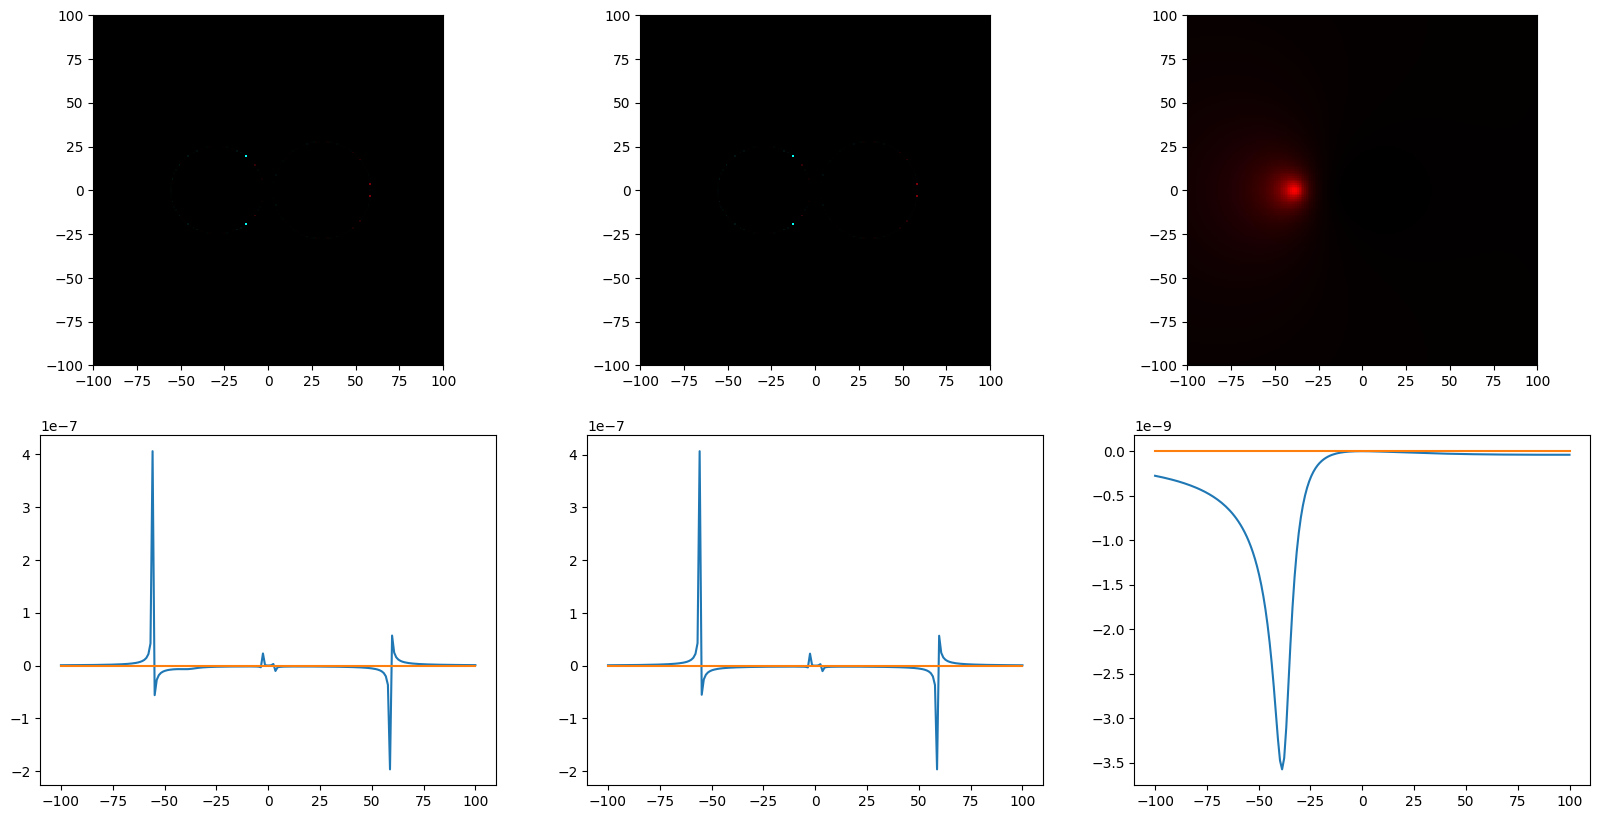

In [6]:
full_integrand.plot_threshold_subtraction((-100,100),(-100,100),x_axis=np.array([0,0,1]))

In [7]:
reference_values = []
p2s_ref = np.linspace(170,220, 225)
for p2 in p2s_ref:
    ctx.set_anomalous_configuration(p2 = p2)
    reference_values.append(ctx.get_reference())

integral_values = []
p2s = np.linspace(175,215, 20)
for p2 in tqdm(p2s):
    ctx.set_anomalous_configuration(p2 = p2)
    ci = ComplexIntegrator(3)
    res = ci.integrate(full_integrand.eval, spherical, 50, 500, rng)
    integral_values.append(res)
    
integral_values = np.array(integral_values)
reference_values = np.array(reference_values)

100%|██████████| 20/20 [00:53<00:00,  2.67s/it]


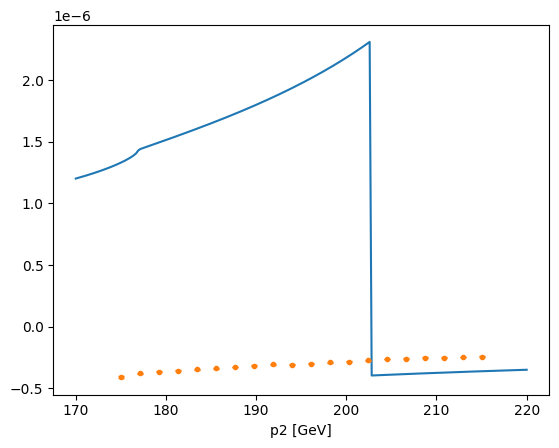

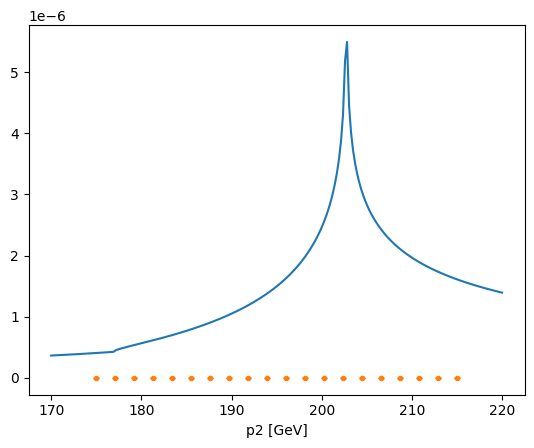

In [8]:
plt.plot(p2s_ref, reference_values.real)

r_avg = np.array([v.real_avg for v in integral_values])
r_err = np.array([v.real_err for v in integral_values])

im_avg = np.array([v.imag_avg for v in integral_values])
im_err = np.array([v.imag_err for v in integral_values])

plt.errorbar(p2s, r_avg,r_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

plt.plot(p2s_ref, reference_values.imag)
plt.errorbar(p2s, im_avg,im_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

In [9]:
regularization = 1e-2
reference_values = []
p2s_ref = np.linspace(170,220, 225)
for p2 in p2s_ref:
    ctx.set_anomalous_configuration(p2 = p2)
    ctx.masses = [m-1j*regularization for m in ctx.masses]
    reference_values.append(ctx.get_reference())

integral_values = []
p2s = np.linspace(175,215, 20)
for p2 in tqdm(p2s):
    ctx.set_anomalous_configuration(p2 = p2)
    ctx.masses = [m-1j*regularization for m in ctx.masses]
    ci = ComplexIntegrator(3)
    res = ci.integrate(full_integrand.eval, spherical, 50, 500, rng)
    integral_values.append(res)
    
integral_values = np.array(integral_values)
reference_values = np.array(reference_values)

100%|██████████| 20/20 [00:54<00:00,  2.74s/it]


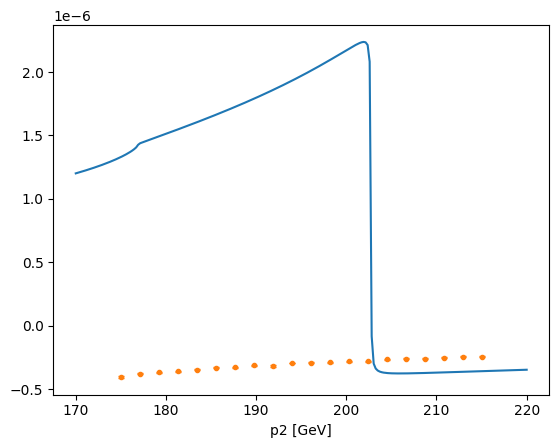

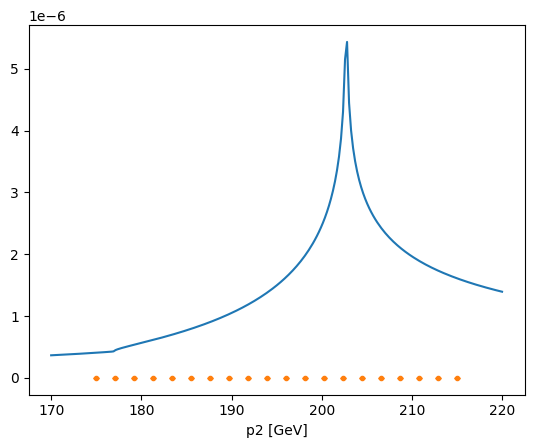

In [10]:
plt.plot(p2s_ref, reference_values.real)

r_avg = np.array([v.real_avg for v in integral_values])
r_err = np.array([v.real_err for v in integral_values])

im_avg = np.array([v.imag_avg for v in integral_values])
im_err = np.array([v.imag_err for v in integral_values])

plt.errorbar(p2s, r_avg,r_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

plt.plot(p2s_ref, reference_values.imag)
plt.errorbar(p2s, im_avg,im_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

# It seems like spurious solutions in e_23 are found, let's plot to verify 

In [11]:
ctx.set_anomalous_configuration(p2 = 203.5)
ctx.origin= np.array([0,0,0,-30])
plotter = unsubtracted.plot_contour((-20,20), (-20,20), (-20,20), 100, invert = True)
plotter.show_grid()
plotter.show()
plotter = counterterm.plot_contour((-20,20), (-20,20), (-20,20), 100, invert = True)
plotter.show_grid()
plotter.show()

Widget(value='<iframe src="http://localhost:36253/index.html?ui=P_0x78b1b6ee0dd0_0&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:36253/index.html?ui=P_0x78b1b71d1c70_1&reconnect=auto" class="pyvi…

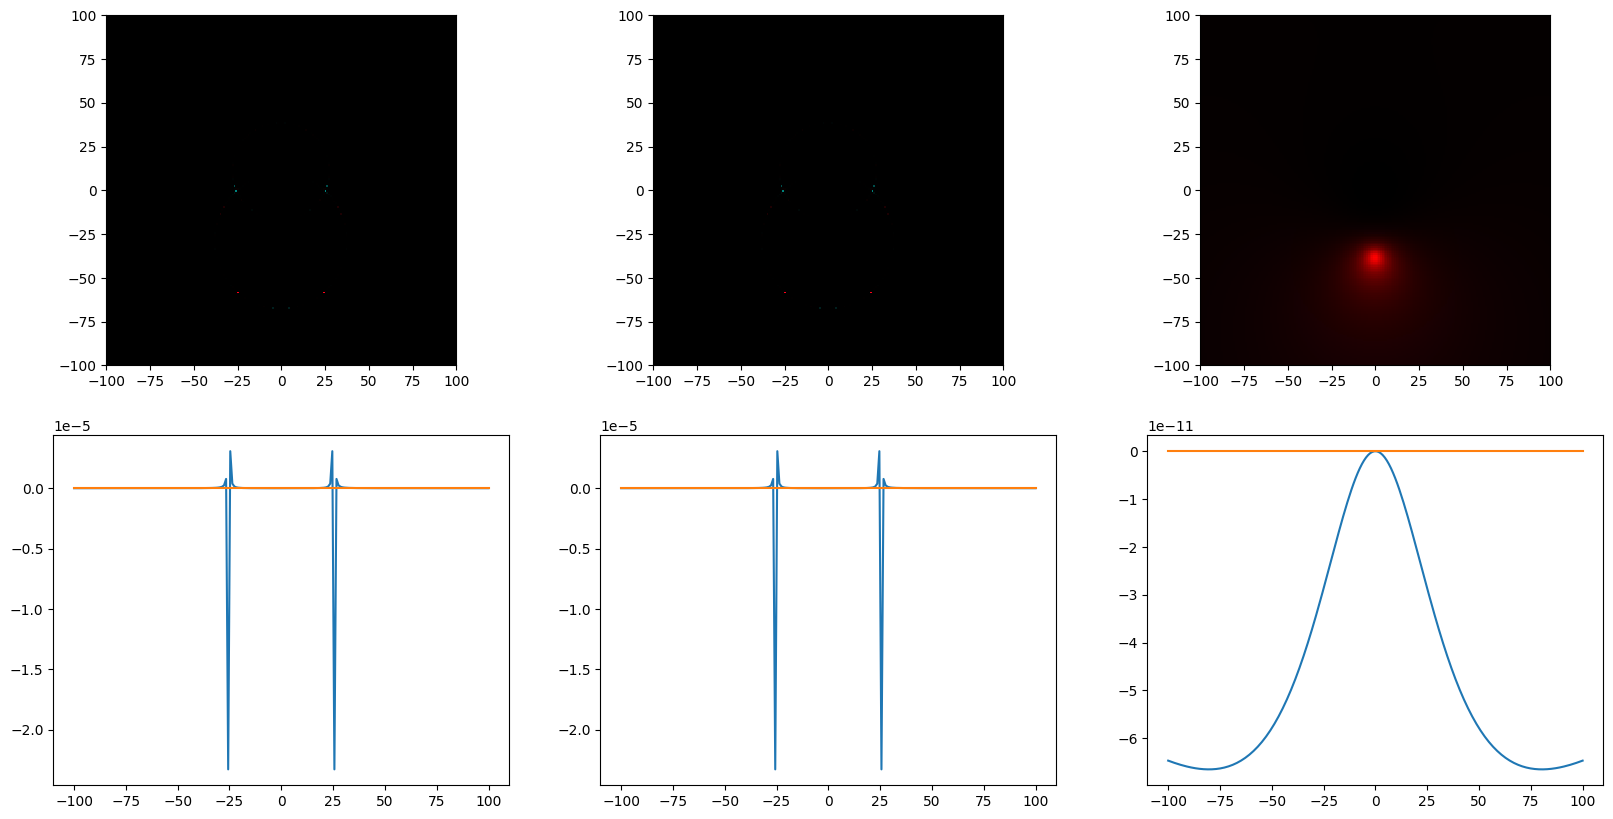

In [12]:
ctx.set_anomalous_configuration(215)

full_integrand.plot_threshold_subtraction((-100,100),(-100,100),y_axis=np.array([0,0,1]))